In [8]:
import parselmouth
import matplotlib.pyplot as plt
from audiochains.streams import StreamFromFile
from audiochains.block_methods import UnpackRawInFloat32
import numpy as np
import time   # Переименование модуля time
import os

from kiwisolver import strength

In [12]:
def process_intensity_file(
    audio_file,
    praat_file=None,
    blocksize=1024,
    samplerate=16000,
    game_duration=10.0,
    intensity_max=100,
    plot_results=True
):
    """
    Анализ интенсивности (громкости) из аудиофайла (имитация реального времени).
    Параллельно можно наложить интенсивность из файла Praat.
    """

    # Переменные для реального времени (RT)
    times = []
    intensities = []
    block_times = []

    # Если хотим график Praat (интенсивность, а не pitch)
    praat_times = []
    praat_intensities = []

    if praat_file is not None:
        try:
            with open(praat_file, "r", encoding="utf-8") as pf:
                header_skipped = False
                for line in pf:
                    line = line.strip()
                    if not line:
                        continue  # Пропускаем пустые строки

                    # Пропускаем заголовок, если есть
                    if not header_skipped:
                        header_skipped = True
                        continue

                    # Читаем время и интенсивность
                    try:
                        t_str, int_str = line.split()
                        t_val = float(t_str)
                        i_val = float(int_str) if int_str.replace('.', '', 1).isdigit() else np.nan
                        praat_times.append(t_val)
                        praat_intensities.append(i_val)
                    except ValueError:
                        print(f"Ошибка парсинга строки в Praat-файле: {line}")

            print(f"Файл Praat загружен успешно: {len(praat_times)} значений.")
        except Exception as e:
            print(f"Ошибка чтения Praat-файла '{praat_file}': {e}")

    # --- Создаем окно для "реального времени" ---
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("Интенсивность (dB)")
    ax.set_title("График интенсивности (имитация реального времени)")
    ax.set_xlim(0, game_duration)
    ax.set_ylim(0, intensity_max)
    ax.grid()

    line_intensity, = ax.plot([], [], color="red", label="Интенсивность (dB)")
    if praat_times and praat_intensities:
        line_praat, = ax.plot([], [], color="blue", linestyle="--", label="Praat (Int)")
    plt.legend()
    plt.show(block=False)

    # Запускаем чтение файла в StreamFromFile
    with StreamFromFile(filename=audio_file, blocksize=blocksize) as sf:
        # Устанавливаем метод извлечения данных
        sf.set_methods(UnpackRawInFloat32())
        print(f"Частота дискретизации (по метаданным): {sf.samplerate} Гц")

        start_time = time.time()
        current_time = 0.0

        while (time.time() - start_time) < game_duration:
            block_start = time.time()

            raw_data = sf.read(blocksize)
            if not raw_data:
                print("Файл прочитан полностью или данных нет. Останавливаемся.")
                break

            # Преобразуем аудиоданные
            signal = sf.chain_of_methods(raw_data)
            sound = parselmouth.Sound(values=signal, sampling_frequency=sf.samplerate)

            # Извлекаем интенсивность
            intensity_obj = sound.to_intensity()
            intensity_values = intensity_obj.values.T.flatten()
            avg_intensity = np.mean(intensity_values) if len(intensity_values) > 0 else 0.0

            # Запоминаем данные
            times.append(current_time)
            intensities.append(avg_intensity)

            # Обновляем график "реального времени"
            line_intensity.set_xdata(times)
            line_intensity.set_ydata(intensities)
            ax.set_xlim(0, max(game_duration, current_time + 1))
            ax.set_ylim(0, intensity_max)

            if praat_times and praat_intensities:
                line_praat.set_xdata(praat_times)
                line_praat.set_ydata(praat_intensities)

            plt.draw()
            plt.pause(0.01)

            block_end = time.time()
            block_time = block_end - block_start
            block_times.append(block_time)

            # Увеличиваем время (для оси X)
            current_time += blocksize / samplerate

    # --- Завершили чтение (или время вышло). Выводим среднее время обработки ---
    if block_times:
        avg_block_time = np.mean(block_times)
        print(f"Среднее время обработки блока: {avg_block_time:.6f} секунд")
    else:
        print("Данные не были обработаны.")

    # --- Итоговый график после завершения ---
    if plot_results:
        plt.figure(figsize=(10, 5))
        plt.xlabel("Время (с)")
        plt.ylabel("Интенсивность (dB)")
        plt.title("Финальный график интенсивности (после обработки)")
        plt.xlim(0, max(times) if times else game_duration)
        plt.ylim(0, intensity_max)
        plt.grid()
        plt.plot(times, intensities, color="red", label="Интенсивность (dB)")
        if praat_times and praat_intensities:
            plt.plot(praat_times, praat_intensities, color="blue", linestyle="--", label="Praat (Int)")
        plt.legend()
        plt.show()

    print("Анализ интенсивности завершён.")


Файл Praat загружен успешно: 1039 значений.


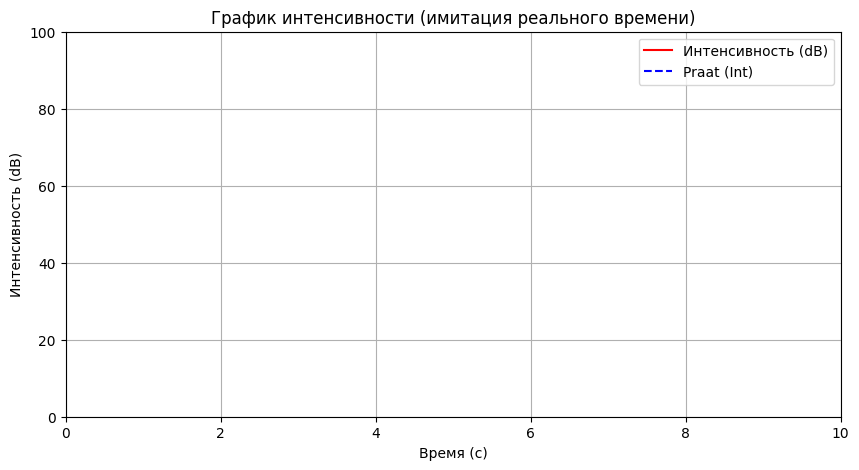

Частота дискретизации (по метаданным): 16000 Гц


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Среднее время обработки блока: 0.015362 секунд


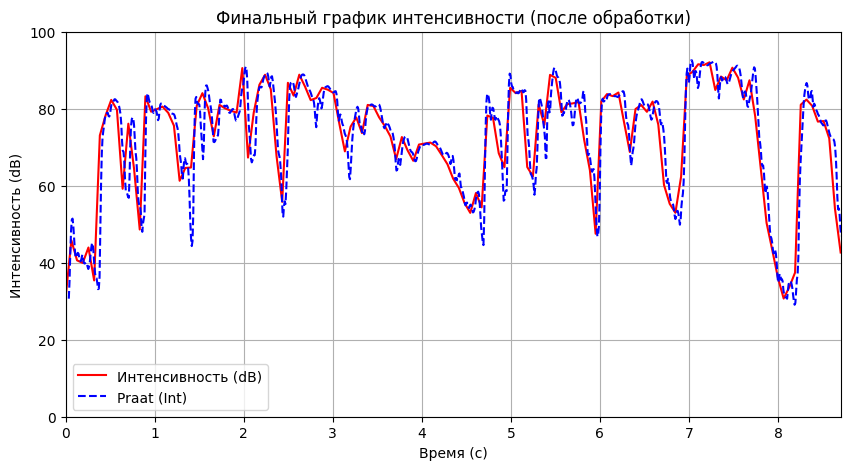

Анализ интенсивности завершён.


In [14]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Перемещаемся на уровень вверх
audio1 = os.path.join(BASE_DIR, 'silero_vad/files/test1nonoise.wav')
praat1 = os.path.join(BASE_DIR, 'silero_vad/files/inttest1nonoise.txt')

process_intensity_file(
        audio_file=audio1,
        praat_file=praat1,
        blocksize=1024,    # читаем по 1024 семпла
        samplerate=16000,  # "виртуальная" частота дискретизации
        game_duration=10.0,# имитируем 10 сек RT
        intensity_max=100, # максимум по оси Y
        plot_results=True
    )